# feishuv2 — DeepLOB: Intraday OFI + OHLCV

Single DeepLOB model trained on **259 features per asset per day**:
- **240 OFI features** — order-flow imbalance at every intraday slot × level (**24 slots × 10 levels**, concatenated slot-major), 5-day rolling z-scored per feature
- **19 OHLCV features** — 14 engineered (momentum, volatility, liquidity, price-structure) + 5 raw (open, close, volume, low, high), cross-sectionally z-scored per day

**Output**: P(down / flat / up) per asset.
**Labels**: return of entering at day-*t* vwap and exiting at the day-*(t+1)* close — (close₍ₜ₊₁₎ − vwapₜ) / vwapₜ vs ±ALPHA.

In [24]:
import os
import random
import warnings
import json as _json

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from datetime import datetime
from sklearn.metrics import classification_report, accuracy_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ── reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print("device:", device)

# ── DataLoader tuning — conditional on device ─────────────────────────────────
PIN_MEMORY = device.type == "cuda"
NUM_WORKERS = 0 if device.type in ("mps", "cpu") else 4

# ── paths ─────────────────────────────────────────────────────────────────────
DATA_DIR = "./data"
CKPT_DIR = "./checkpoints_v2"
CACHE_DIR = "./cache/daily_windows"
LOB_PARQUET = os.path.join(DATA_DIR, "lob_data_in_sample.parquet")
OHLCV_PARQUET = os.path.join(DATA_DIR, "daily_data_in_sample.parquet")  # ← set your path

# ── model / label config ──────────────────────────────────────────────────────
T = 50  # lookback window (trading days)
ALPHA = 0.015  # ±0.2 % threshold on (close_{t+1} − vwap_t) / vwap_t
N_LEVELS = 10  # LOB depth
N_SLOTS = 24  # fixed intraday snapshots per day (09:40 … 15:00, 10-min grid)
N_OFI = N_SLOTS * N_LEVELS  # 240 concatenated intraday OFI features
N_OHLCV_ENG = 14  # engineered OHLCV features
N_OHLCV_RAW = 5  # raw OHLCV: open, close, volume, low, high
N_OHLCV = N_OHLCV_ENG + N_OHLCV_RAW  # 19
NF = N_OFI + N_OHLCV  # 259 total input features per day
N_CLASSES = 3  # 0=down  1=flat  2=up
OFI_NORM_DAYS = 5  # rolling look-back days for OFI z-score

TRAIN_FRAC = 0.70  # per-asset chronological split: train / val / test
VAL_FRAC = 0.85  # cumulative fraction; val = [TRAIN_FRAC, VAL_FRAC), test = rest

BATCH_SIZE = 64
LR = 1e-4
EPOCHS = 10
CKPT_EVERY = 5

os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)

device: cuda


---
## 1. Data Pipeline

1. Stream LOB parquet → aggregate intraday OFI to **daily mean** → 5-day rolling z-score
2. Load daily OHLCV → engineer 14 features → **cross-sectional z-score** per day
3. Merge → build labels → slide T=50 day windows → write **HDF5 cache** (never loads all data into RAM)

### 1.1 Paths & download

In [25]:
try:
    import gdown
except ImportError:
    import subprocess
    import sys

    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gdown"])
    import gdown

GDRIVE_FILE_ID = "1-WcOlKbgIN7A6TkyHj_8kikpaCMluf3L"  # ← fill in if needed

if not os.path.exists(LOB_PARQUET):
    print(f"LOB parquet not found — downloading (id={GDRIVE_FILE_ID})...")
    os.makedirs(DATA_DIR, exist_ok=True)
    gdown.download(id=GDRIVE_FILE_ID, output=LOB_PARQUET, quiet=False)
else:
    print(f"LOB  : {LOB_PARQUET}  ({os.path.getsize(LOB_PARQUET) / 1e9:.2f} GB)")

if not os.path.exists(OHLCV_PARQUET):
    raise FileNotFoundError(f"OHLCV parquet not found: {OHLCV_PARQUET}\nPlease set OHLCV_PARQUET.")
else:
    print(f"OHLCV: {OHLCV_PARQUET}  ({os.path.getsize(OHLCV_PARQUET) / 1e6:.1f} MB)")

LOB  : ./data/lob_data_in_sample.parquet  (2.19 GB)
OHLCV: ./data/daily_data_in_sample.parquet  (33.6 MB)


### 1.2 Disk I/O utilities

In [11]:
import h5py


class WindowWriter:
    """Append-mode HDF5 writer for (X, y, aidx) window tuples."""

    def __init__(self, cache_dir: str, split: str):
        os.makedirs(cache_dir, exist_ok=True)
        self.path = os.path.join(cache_dir, f"{split}.h5")

    def __enter__(self):
        self._f = h5py.File(self.path, "w")
        self._f.create_dataset(
            "X",
            shape=(0, T, NF),
            maxshape=(None, T, NF),
            dtype="float32",
            chunks=(512, T, NF),
        )
        self._f.create_dataset("y", shape=(0,), maxshape=(None,), dtype="int64", chunks=(8192,))
        self._f.create_dataset("aidx", shape=(0,), maxshape=(None,), dtype="int64", chunks=(8192,))
        self.n = 0
        return self

    def write(self, X, y, aidx):
        n = len(y)
        if n == 0:
            return
        for key, arr in (("X", X), ("y", y), ("aidx", aidx)):
            ds = self._f[key]
            ds.resize(ds.shape[0] + n, axis=0)
            ds[-n:] = arr
        self.n += n

    def __exit__(self, *_):
        self._f.close()


class DiskLOBDataset(Dataset):
    """Lazy HDF5 dataset; multiprocessing-safe (opens file handle per worker)."""

    def __init__(self, split: str, cache_dir: str = CACHE_DIR):
        self.path = os.path.join(cache_dir, f"{split}.h5")
        with h5py.File(self.path, "r") as f:
            self.n = f["X"].shape[0]
        self._fh = None

    def _open(self):
        if self._fh is None:
            self._fh = h5py.File(self.path, "r")
        return self._fh

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        f = self._open()
        X = torch.from_numpy(f["X"][idx][np.newaxis])  # (1, T, NF)
        y = torch.tensor(int(f["y"][idx]))
        aidx = torch.tensor(int(f["aidx"][idx]))
        return X, y, aidx

    def __del__(self):
        if self._fh is not None:
            try:
                self._fh.close()
            except Exception:
                pass


def _meta_path(cache_dir):
    return os.path.join(cache_dir, "meta.json")


def save_cache_meta(cache_dir, all_assets, asset_to_idx):
    with open(_meta_path(cache_dir), "w") as f:
        _json.dump({"all_assets": all_assets, "asset_to_idx": asset_to_idx}, f)


def load_cache_meta(cache_dir):
    with open(_meta_path(cache_dir)) as f:
        m = _json.load(f)
    return m["all_assets"], m["asset_to_idx"]


def cache_exists(cache_dir=CACHE_DIR):
    return all(
        os.path.exists(os.path.join(cache_dir, n))
        for n in ("train.h5", "val.h5", "test.h5", "meta.json")
    )


def print_cache_info(cache_dir=CACHE_DIR):
    print(f"Cache: {cache_dir}")
    for split in ("train", "val", "test"):
        with h5py.File(os.path.join(cache_dir, f"{split}.h5"), "r") as f:
            n = f["X"].shape[0]
            lc = np.bincount(f["y"][:], minlength=N_CLASSES)
        mb = n * T * NF * 4 / 1e6
        print(f"  {split:5s}  n={n:>9,}  ({mb:6.0f} MB)  ↓{lc[0]:,}  ={lc[1]:,}  ↑{lc[2]:,}")

### 1.3 OFI helpers

In [27]:
ASK_P = [f"ask_price_{i}" for i in range(1, N_LEVELS + 1)]
BID_P = [f"bid_price_{i}" for i in range(1, N_LEVELS + 1)]
ASK_V = [f"ask_volume_{i}" for i in range(1, N_LEVELS + 1)]
BID_V = [f"bid_volume_{i}" for i in range(1, N_LEVELS + 1)]
RAW_COLS = ASK_P + BID_P + ASK_V + BID_V
STREAM_COLS = ["asset_id", "trade_day_id", "time"] + RAW_COLS
L1_COLS = ["ask_price_1", "bid_price_1", "ask_volume_1", "bid_volume_1"]
STREAM_BATCH = 500_000

# ── fixed intraday time grid: 24 slots (09:40 … 11:20, 13:00 … 15:00) ─────────
INTRADAY_SLOTS = [
    "09:40:00",
    "09:50:00",
    "10:00:00",
    "10:10:00",
    "10:20:00",
    "10:30:00",
    "10:40:00",
    "10:50:00",
    "11:00:00",
    "11:10:00",
    "11:20:00",
    "13:00:00",
    "13:10:00",
    "13:20:00",
    "13:30:00",
    "13:40:00",
    "13:50:00",
    "14:00:00",
    "14:10:00",
    "14:20:00",
    "14:30:00",
    "14:40:00",
    "14:50:00",
    "15:00:00",
]
SLOT_TO_IDX = {t: i for i, t in enumerate(INTRADAY_SLOTS)}
assert len(INTRADAY_SLOTS) == N_SLOTS


def _bOF(b_price, b_vol):
    up = b_price > b_price.shift(1)
    same = b_price == b_price.shift(1)
    dn = b_price < b_price.shift(1)
    return up * b_vol + same * (b_vol - b_vol.shift(1)) + dn * (-b_vol.shift(1))


def _aOF(a_price, a_vol):
    up = a_price > a_price.shift(1)
    same = a_price == a_price.shift(1)
    dn = a_price < a_price.shift(1)
    return up * (-a_vol.shift(1)) + same * (a_vol - a_vol.shift(1)) + dn * a_vol


def _OFI(bp, bv, ap, av):
    return _bOF(bp, bv) - _aOF(ap, av)


def ofi_to_daily_concat_normed(df: pd.DataFrame) -> pd.DataFrame:
    """
    Per-asset intraday LOB (sorted by trade_day_id, time) → one row per day with
    N_SLOTS × N_LEVELS = 240 features: the intraday OFI at every (time-slot, level),
    concatenated slot-major [slot0_lvl1..lvl10, slot1_lvl1..lvl10, …]. Each of the
    240 features is z-scored using only the OFI_NORM_DAYS preceding days (no
    look-ahead). Missing intraday slots are zero-filled.
    """
    # ── 1. intraday OFI at each level (per tick) ───────────────────────────
    ofi_arr = np.zeros((len(df), N_LEVELS), dtype=np.float32)
    for i in range(N_LEVELS):
        j = i + 1
        ofi = _OFI(
            df[f"bid_price_{j}"],
            df[f"bid_volume_{j}"].fillna(0.0),
            df[f"ask_price_{j}"],
            df[f"ask_volume_{j}"].fillna(0.0),
        ).fillna(0.0)
        ofi_arr[:, i] = ofi.values

    # ── 2. place each tick into its (day, slot) cell → (n_days, 24, 10) ────
    days = df["trade_day_id"].values
    slot = df["time"].map(SLOT_TO_IDX).to_numpy()  # NaN for any off-grid time
    unique_days, inv = np.unique(days, return_inverse=True)
    n_days = len(unique_days)

    grid = np.zeros((n_days, N_SLOTS, N_LEVELS), dtype=np.float32)
    keep = ~pd.isna(slot)
    grid[inv[keep], slot[keep].astype(np.int64), :] = ofi_arr[keep]
    daily = grid.reshape(n_days, N_SLOTS * N_LEVELS)  # 240, slot-major

    # ── 3. rolling z-score per feature (past OFI_NORM_DAYS days only) ──────
    normed = np.empty_like(daily)
    for d in range(n_days):
        past = daily[max(0, d - OFI_NORM_DAYS) : d]
        if len(past) >= 2:
            mu, std = past.mean(0), past.std(0)
        elif len(past) == 1:
            mu, std = past[0], np.zeros(daily.shape[1], dtype=np.float32)
        else:
            mu = np.zeros(daily.shape[1], dtype=np.float32)
            std = np.ones(daily.shape[1], dtype=np.float32)
        normed[d] = (daily[d] - mu) / (std + 1e-9)

    cols = {f"ofi_{i + 1}": normed[:, i] for i in range(N_SLOTS * N_LEVELS)}
    cols["date"] = unique_days
    return pd.DataFrame(cols)

### 1.4 Stream LOB → daily OFI

In [28]:
import pyarrow.parquet as pq

pf = pq.ParquetFile(LOB_PARQUET)
asset_lob_chunks: dict = {}
total_rows = 0

print(f"Streaming {LOB_PARQUET}  (batch={STREAM_BATCH:,} rows)…")
for _batch in pf.iter_batches(batch_size=STREAM_BATCH, columns=STREAM_COLS):
    _df = _batch.to_pandas()
    total_rows += len(_df)
    _df = _df[_df[L1_COLS].notna().all(axis=1)]
    for _aid, _grp in _df.groupby("asset_id", sort=False):
        asset_lob_chunks.setdefault(_aid, []).append(_grp)
    print(f"  rows={total_rows:,}  assets={len(asset_lob_chunks)}", end="\r")
del _batch, _df
print(f"\nDone. total rows={total_rows:,}  assets={len(asset_lob_chunks)}")

# ── per-asset: concat → sort → concatenated intraday OFI → free raw data ─────
ofi_frames = []
for asset_id in tqdm(sorted(asset_lob_chunks), desc="Daily OFI"):
    chunks = asset_lob_chunks.pop(asset_id)
    df = (
        pd.concat(chunks, ignore_index=True)
        .sort_values(["trade_day_id", "time"])
        .reset_index(drop=True)
    )
    del chunks
    if len(df) < 2:
        continue
    daily_df = ofi_to_daily_concat_normed(df)
    daily_df["asset_id"] = asset_id
    ofi_frames.append(daily_df)
    del df

ofi_daily = pd.concat(ofi_frames, ignore_index=True)
del ofi_frames, asset_lob_chunks
OFI_COLS = [f"ofi_{i}" for i in range(1, N_OFI + 1)]
all_lob_assets = sorted(ofi_daily["asset_id"].unique().tolist())
print(
    f"Daily OFI: {len(ofi_daily):,} rows  assets={len(all_lob_assets)}  "
    f"ofi_feats={len(OFI_COLS)} (={N_SLOTS}×{N_LEVELS})"
)
ofi_daily.iloc[:3, :6]

Streaming ./data/lob_data_in_sample.parquet  (batch=500,000 rows)…
  rows=24,810,697  assets=2270
Done. total rows=24,810,697  assets=2270


Daily OFI: 100% 2270/2270 [01:55<00:00, 19.68it/s]


Daily OFI: 1,057,338 rows  assets=2270  ofi_feats=240 (=24×10)


,ofi_1,ofi_2,ofi_3,ofi_4,ofi_5,ofi_6
0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
1,-5.647720e+14,-6.575000e+14,-4.580000e+14,-2.963000e+14,-2.592000e+14,-1.793000e+14
2,2.584356e+00,2.024183e+00,2.862882e+00,5.122173e+00,2.999228e+00,3.499721e+00


### 1.5 OHLCV features

In [29]:
ohlcv_raw = pd.read_parquet(OHLCV_PARQUET)

# normalise column names
if "trade_day_id" in ohlcv_raw.columns and "date" not in ohlcv_raw.columns:
    ohlcv_raw = ohlcv_raw.rename(columns={"trade_day_id": "date"})

# keep only assets present in the LOB data
ohlcv_raw = ohlcv_raw[ohlcv_raw["asset_id"].isin(all_lob_assets)].copy()
ohlcv_raw = ohlcv_raw.sort_values(["asset_id", "date"]).reset_index(drop=True)
print(f"OHLCV raw: {len(ohlcv_raw):,} rows  assets={ohlcv_raw['asset_id'].nunique()}")
# required: asset_id, date, open, high, low, close, volume, vwap_0930_0935
print("columns:", list(ohlcv_raw.columns))

VWAP_COL = "vwap_0930_0935"  # day-t entry price reference


def _build_asset_ohlcv_feats(g: pd.DataFrame) -> pd.DataFrame:
    """Compute 14 engineered + 5 raw OHLCV features for one asset (sorted by date)."""
    c = g["close"].values.astype(np.float64)
    o = g["open"].values.astype(np.float64)
    h = g["high"].values.astype(np.float64)
    lo = g["low"].values.astype(np.float64)
    v = g["volume"].values.astype(np.float64)
    if VWAP_COL in g.columns:
        vw = g[VWAP_COL].values.astype(np.float64)
    elif "vwap" in g.columns:
        vw = g["vwap"].values.astype(np.float64)
    else:
        vw = c.copy()
    n = len(c)

    log_ret = np.empty(n)
    log_ret[0] = 0.0
    log_ret[1:] = np.log(c[1:] / (c[:-1] + 1e-9))

    def ret_n(k):
        r = np.full(n, np.nan)
        r[k:] = c[k:] / (c[:-k] + 1e-9) - 1
        return r

    def roll_std(k):
        return pd.Series(log_ret).rolling(k, min_periods=k).std().values

    def roll_mean(k):
        return pd.Series(c).rolling(k, min_periods=k).mean().values

    # RSI-14
    delta = pd.Series(c).diff()
    gain = delta.clip(lower=0).rolling(14, min_periods=14).mean()
    loss = (-delta.clip(upper=0)).rolling(14, min_periods=14).mean()
    rsi = (100 - 100 / (1 + gain / (loss + 1e-9))).values

    # Amihud illiquidity
    amihud = np.abs(ret_n(1)) / (v * c + 1e-9)

    # volume z-score (20-day rolling)
    vs = pd.Series(v)
    vol_z = (
        (vs - vs.rolling(20, min_periods=5).mean()) / (vs.rolling(20, min_periods=5).std() + 1e-9)
    ).values

    feats = {
        # ── engineered ──
        "ret_1d": ret_n(1),
        "ret_5d": ret_n(5),
        "ret_10d": ret_n(10),
        "ret_20d": ret_n(20),
        "vol_5d": roll_std(5),
        "vol_20d": roll_std(20),
        "amihud": amihud,
        "volume_zscore": vol_z,
        "rsi_14": rsi,
        "ma_dist_5": c / (roll_mean(5) + 1e-9) - 1,
        "ma_dist_20": c / (roll_mean(20) + 1e-9) - 1,
        "open_close_ret": c / (o + 1e-9) - 1,
        "high_low_range": (h - lo) / (c + 1e-9),
        "close_vwap_dist": c / (vw + 1e-9) - 1,
        # ── raw OHLCV (z-scored cross-sectionally below) ──
        "raw_open": o,
        "raw_close": c,
        "raw_volume": v,
        "raw_low": lo,
        "raw_high": h,
    }
    out = pd.DataFrame(feats, index=g.index)
    out["asset_id"] = g["asset_id"].values
    out["date"] = g["date"].values
    return out


OHLCV_ENG_COLS = [
    "ret_1d",
    "ret_5d",
    "ret_10d",
    "ret_20d",
    "vol_5d",
    "vol_20d",
    "amihud",
    "volume_zscore",
    "rsi_14",
    "ma_dist_5",
    "ma_dist_20",
    "open_close_ret",
    "high_low_range",
    "close_vwap_dist",
]
OHLCV_RAW_COLS = ["raw_open", "raw_close", "raw_volume", "raw_low", "raw_high"]
OHLCV_COLS = OHLCV_ENG_COLS + OHLCV_RAW_COLS  # 14 + 5 = 19

feat_frames = [
    _build_asset_ohlcv_feats(g)
    for _, g in tqdm(ohlcv_raw.groupby("asset_id", sort=False), desc="OHLCV features")
]
ohlcv_feats = pd.concat(feat_frames, ignore_index=True)
del feat_frames


# cross-sectional z-score per day (engineered + raw alike)
def _cs_z(s):
    mu, std = s.mean(), s.std()
    return (s - mu) / (std + 1e-9)


for col in OHLCV_COLS:
    ohlcv_feats[col] = ohlcv_feats.groupby("date")[col].transform(_cs_z)

print(f"OHLCV features: {len(ohlcv_feats):,} rows  cols={len(OHLCV_COLS)} (14 eng + 5 raw)")
ohlcv_feats[["asset_id", "date"] + OHLCV_RAW_COLS].head(3)

OHLCV raw: 1,060,121 rows  assets=2270
columns: ['asset_id', 'date', 'open', 'high', 'low', 'close', 'volume', 'amount', 'adj_factor', 'vwap_0930_0935']


OHLCV features: 100% 2270/2270 [00:08<00:00, 277.52it/s]


OHLCV features: 1,060,121 rows  cols=19 (14 eng + 5 raw)


,asset_id,date,raw_open,raw_close,raw_volume,raw_low,raw_high
0,A000001,D001,-0.378570,-0.380251,-0.021087,-0.378528,-0.380706
1,A000001,D002,-0.381010,-0.380556,-0.066525,-0.378247,-0.382847
2,A000001,D003,-0.380245,-0.376977,-0.008897,-0.376806,-0.380631


### 1.6 Labels & window cache

In [30]:
FEAT_COLS = OFI_COLS + OHLCV_COLS  # 240 + 19 = 259 features, order matters


def build_labels(close: np.ndarray, vwap: np.ndarray) -> np.ndarray:
    """
    Label at day t from the return of entering at day-t vwap and exiting at the
    day-(t+1) close:  (close[t+1] - vwap[t]) / vwap[t]  vs  ±ALPHA.
    Returns int64 array: 0=down  1=flat  2=up  -1=invalid (last row).
    """
    n = len(close)
    labels = np.full(n, -1, dtype=np.int64)
    for i in range(n - 1):
        ret = (close[i + 1] - vwap[i]) / (abs(vwap[i]) + 1e-9)
        if ret > ALPHA:
            labels[i] = 2
        elif ret < -ALPHA:
            labels[i] = 0
        else:
            labels[i] = 1
    return labels


def build_windows(feat: np.ndarray, labels: np.ndarray):
    """Slide a T-day window; skip steps where label == -1."""
    Xws, yws = [], []
    for i in range(len(labels) - T + 1):
        lbl = labels[i + T - 1]
        if lbl == -1:
            continue
        Xws.append(feat[i : i + T])
        yws.append(lbl)
    if not Xws:
        return (np.empty((0, T, feat.shape[1]), np.float32), np.empty(0, np.int64))
    return np.stack(Xws).astype(np.float32), np.array(yws, np.int64)


if cache_exists():
    print(f"Cache found at {CACHE_DIR} — skipping window computation.")
    all_assets, asset_to_idx = load_cache_meta(CACHE_DIR)
else:
    # ── merge concat-OFI + OHLCV features + raw close & vwap (for labels) ────
    daily = ofi_daily.merge(
        ohlcv_feats[["asset_id", "date"] + OHLCV_COLS],
        on=["asset_id", "date"],
        how="inner",
    ).merge(
        ohlcv_raw[["asset_id", "date", "close", VWAP_COL]],
        on=["asset_id", "date"],
        how="inner",
    )
    daily = daily.sort_values(["asset_id", "date"]).reset_index(drop=True)

    all_assets = sorted(daily["asset_id"].unique().tolist())
    asset_to_idx = {aid: i for i, aid in enumerate(all_assets)}
    skipped = 0

    # Per-asset chronological split: train / val / test (time-ordered → no leakage).
    with (
        WindowWriter(CACHE_DIR, "train") as wtr,
        WindowWriter(CACHE_DIR, "val") as wvl,
        WindowWriter(CACHE_DIR, "test") as wts,
    ):
        for asset_id, g in tqdm(daily.groupby("asset_id", sort=False), desc="Building windows"):
            g = g.sort_values("date").reset_index(drop=True)
            if len(g) < T + 6:
                skipped += 1
                continue

            labels = build_labels(g["close"].values, g[VWAP_COL].values)

            feat = g[FEAT_COLS].values.astype(np.float32)
            np.nan_to_num(feat, copy=False, nan=0.0, posinf=5.0, neginf=-5.0)
            np.clip(feat, -5.0, 5.0, out=feat)

            X_w, y_w = build_windows(feat, labels)
            if len(y_w) == 0:
                skipped += 1
                continue

            n_total = len(y_w)
            n_train = int(TRAIN_FRAC * n_total)
            n_val = int(VAL_FRAC * n_total)
            a_idx = np.full(n_total, asset_to_idx[asset_id], dtype=np.int64)

            wtr.write(X_w[:n_train], y_w[:n_train], a_idx[:n_train])
            wvl.write(X_w[n_train:n_val], y_w[n_train:n_val], a_idx[n_train:n_val])
            wts.write(X_w[n_val:], y_w[n_val:], a_idx[n_val:])

    save_cache_meta(CACHE_DIR, all_assets, asset_to_idx)
    del daily
    print(f"\nDone. {len(all_assets) - skipped}/{len(all_assets)} assets (skipped {skipped})")

print_cache_info()

Cache found at ./cache/daily_windows — skipping window computation.
Cache: ./cache/daily_windows
  train  n=  659,256  ( 34149 MB)  ↓181,016  =317,668  ↑160,572
  val    n=  141,472  (  7328 MB)  ↓46,848  =50,794  ↑43,830
  test   n=  142,974  (  7406 MB)  ↓48,292  =57,393  ↑37,289


In [31]:
N_ASSETS = len(all_assets)
print(f"N_ASSETS = {N_ASSETS}")
print(f"Embed dim = {N_ASSETS * 16}")
print(f"NF = {NF}  (N_OFI={N_OFI} + N_OHLCV={N_OHLCV})")
print(
    f"DeepLOB spatial: w1={(NF - 2) // 2 + 1}  w2={(((NF - 2) // 2 + 1) - 2) // 2 + 1}  k3={((((NF - 2) // 2 + 1) - 2) // 2 + 1)}"
)

N_ASSETS = 2270
Embed dim = 36320
NF = 259  (N_OFI=240 + N_OHLCV=19)
DeepLOB spatial: w1=129  w2=64  k3=64


---
## 2. Model

### 2.1 DeepLOB (NF=259, auto-adapts)

Three conv blocks progressively collapse the 259-feature axis to 1, then an Inception module
and LSTM process the time axis. An asset embedding is concatenated before the classification head.

| Stage | Output shape | Notes |
|-------|-------------|-------|
| Conv block 1 | (B, 32, T−6, w1) | stride-2 halves features: NF→129 |
| Conv block 2 | (B, 32, T−18, w2) | stride-2: 129→64 |
| Conv block 3 | (B, 32, T−24, 1) | (1,k3) collapses to 1 |
| Inception | (B, 192, T′, 1) | three parallel branches |
| LSTM | (B, 64) | last hidden state |
| FC | (B, 3) | + asset embed |

In [32]:
class DeepLOB(nn.Module):
    def __init__(self, y_len: int = 3, NF: int = 40, n_assets: int = 1):
        super().__init__()
        embed_dim = n_assets * 8

        # spatial widths after the two stride-2 convolutions
        w1 = (NF - 2) // 2 + 1  # after (1,2) stride-2
        w2 = (w1 - 2) // 2 + 1  # after (1,2) stride-2
        k3 = w2  # (1,k3) collapses spatial dim to 1

        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, (1, 2), stride=(1, 2)),
            nn.LeakyReLU(0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, (4, 1)),
            nn.LeakyReLU(0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, (4, 1)),
            nn.LeakyReLU(0.01),
            nn.BatchNorm2d(32),
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 32, (1, 2), stride=(1, 2)),
            nn.Tanh(),
            nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, (4, 1)),
            nn.Tanh(),
            nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, (4, 1)),
            nn.Tanh(),
            nn.BatchNorm2d(32),
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(32, 32, (1, k3)),
            nn.LeakyReLU(0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, (4, 1)),
            nn.LeakyReLU(0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, (4, 1)),
            nn.LeakyReLU(0.01),
            nn.BatchNorm2d(32),
        )
        self.inp1 = nn.Sequential(
            nn.Conv2d(32, 64, (1, 1), padding="same"),
            nn.LeakyReLU(0.01),
            nn.BatchNorm2d(64),
            nn.Conv2d(64, 64, (3, 1), padding="same"),
            nn.LeakyReLU(0.01),
            nn.BatchNorm2d(64),
        )
        self.inp2 = nn.Sequential(
            nn.Conv2d(32, 64, (1, 1), padding="same"),
            nn.LeakyReLU(0.01),
            nn.BatchNorm2d(64),
            nn.Conv2d(64, 64, (5, 1), padding="same"),
            nn.LeakyReLU(0.01),
            nn.BatchNorm2d(64),
        )
        self.inp3 = nn.Sequential(
            nn.MaxPool2d((3, 1), stride=(1, 1), padding=(1, 0)),
            nn.Conv2d(32, 64, (1, 1), padding="same"),
            nn.LeakyReLU(0.01),
            nn.BatchNorm2d(64),
        )
        self.asset_embed = nn.Embedding(n_assets, embed_dim, max_norm=1.0)
        self.lstm = nn.LSTM(192, 64, num_layers=1, batch_first=True)
        self.fc = nn.Linear(64 + embed_dim, y_len)

    def forward(self, x, asset_idx):
        B = x.size(0)
        h0 = torch.zeros(1, B, 64, device=x.device)
        c0 = torch.zeros(1, B, 64, device=x.device)

        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = torch.cat([self.inp1(x), self.inp2(x), self.inp3(x)], dim=1)  # (B,192,T',1)
        x = x.permute(0, 2, 1, 3).reshape(B, x.shape[2], 192)

        lstm_out, _ = self.lstm(x, (h0, c0))
        embed = self.asset_embed(asset_idx)  # (B, embed_dim)
        combined = torch.cat([lstm_out[:, -1, :], embed], dim=1)  # (B, 64+embed_dim)
        return torch.softmax(self.fc(combined), dim=1)

### 2.2 Training loop

In [33]:
def train_model(model, name, train_loader, val_loader, epochs=EPOCHS, lr=LR, ckpt_every=CKPT_EVERY):
    """
    Train `model` and return (train_losses, val_losses).
    Saves:
      - checkpoints/<name>/best_model.pt          — lowest val-loss weights
      - checkpoints/<name>/ckpt_epoch_NNN.pt      — full state every `ckpt_every` epochs
    """
    ckpt_path = os.path.join(CKPT_DIR, name)
    os.makedirs(ckpt_path, exist_ok=True)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    train_losses, val_losses = [], []
    best_val_loss = np.inf
    best_val_epoch = 0

    for epoch in range(epochs):
        t0 = datetime.now()

        # ── train ────────────────────────────────────────────────────────────
        model.train()
        batch_train = []
        pbar = tqdm(
            train_loader,
            desc=f"{name}  ep {epoch + 1:3d}/{epochs} [train]",
            unit="batch",
            leave=False,
        )
        for X_b, y_b, aidx_b in pbar:
            X_b = X_b.to(device, dtype=torch.float32)
            y_b = y_b.to(device)
            aidx_b = aidx_b.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_b, aidx_b), y_b)
            loss.backward()
            optimizer.step()
            batch_train.append(loss.item())
            pbar.set_postfix(loss=f"{loss.item():.4f}")
        pbar.close()
        train_loss = float(np.mean(batch_train))

        # ── validate ─────────────────────────────────────────────────────────
        model.eval()
        batch_val = []
        pbar = tqdm(
            val_loader,
            desc=f"{name}  ep {epoch + 1:3d}/{epochs} [val]  ",
            unit="batch",
            leave=False,
        )
        with torch.no_grad():
            for X_b, y_b, aidx_b in pbar:
                X_b = X_b.to(device, dtype=torch.float32)
                y_b = y_b.to(device)
                aidx_b = aidx_b.to(device)
                v = criterion(model(X_b, aidx_b), y_b).item()
                batch_val.append(v)
                pbar.set_postfix(loss=f"{v:.4f}")
        pbar.close()
        val_loss = float(np.mean(batch_val))

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        # ── save best model ───────────────────────────────────────────────────
        is_best = val_loss < best_val_loss
        if is_best:
            best_val_loss = val_loss
            best_val_epoch = epoch + 1
            torch.save(model.state_dict(), os.path.join(ckpt_path, "best_model.pt"))

        # ── periodic checkpoint (full state) ──────────────────────────────────
        if (epoch + 1) % ckpt_every == 0:
            torch.save(
                {
                    "epoch": epoch + 1,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "train_loss": train_loss,
                    "val_loss": val_loss,
                },
                os.path.join(ckpt_path, f"ckpt_epoch_{epoch + 1:03d}.pt"),
            )

        dt = datetime.now() - t0
        tqdm.write(
            f"{name}  ep {epoch + 1:3d}/{epochs}  "
            f"train={train_loss:.4f}  val={val_loss:.4f}  "
            f"({dt})  best={best_val_epoch}"
            f"{'  ★' if is_best else ''}"
        )

    return train_losses, val_losses

### 2.3 Evaluation helper

In [34]:
def evaluate_model(model, loader):
    """Return (preds, targets, probs) numpy arrays over the full loader."""
    model.eval()
    all_preds, all_targets, all_probs = [], [], []
    with torch.no_grad():
        for X, y, aidx in loader:
            X, aidx = X.to(device, dtype=torch.float32), aidx.to(device)
            probs = model(X, aidx).cpu().numpy()
            all_probs.append(probs)
            all_preds.append(probs.argmax(axis=1))
            all_targets.append(y.numpy())
    return (
        np.concatenate(all_preds),
        np.concatenate(all_targets),
        np.concatenate(all_probs, axis=0),
    )

---
## 3. Smoke Test

Verify the model forward pass and backward pass with a tiny batch before full training.

In [35]:
from torch.utils.data import Subset

_ds = DiskLOBDataset("train")
_sub = Subset(_ds, list(range(min(32, len(_ds)))))
_ldr = DataLoader(_sub, batch_size=8)
_model = DeepLOB(y_len=N_CLASSES, NF=NF, n_assets=max(1, N_ASSETS)).to(device)

_crit = nn.CrossEntropyLoss()
_X, _y, _aidx = next(iter(_ldr))
_X, _y, _aidx = _X.to(device, dtype=torch.float32), _y.to(device), _aidx.to(device)

_out = _model(_X, _aidx)
_loss = _crit(_out, _y)
_loss.backward()

print(f"Input  shape : {tuple(_X.shape)}")
print(f"Output shape : {tuple(_out.shape)}")
print(f"Loss (random): {_loss.item():.4f}")
print(f"Probs sum    : {_out.sum(dim=1).mean().item():.6f}  (should be ~1.0)")
assert _out.shape == (len(_X), N_CLASSES), "Output shape mismatch"
print("Smoke test passed.")
del _model, _ds, _sub, _ldr

Input  shape : (8, 1, 50, 259)
Output shape : (8, 3)
Loss (random): 1.1008
Probs sum    : 1.000000  (should be ~1.0)
Smoke test passed.


---
## 4. Training

### 4.1 DataLoaders & model

In [36]:
ds = {split: DiskLOBDataset(split) for split in ("train", "val", "test")}
dl = {
    "train": DataLoader(
        ds["train"],
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    ),
    "val": DataLoader(
        ds["val"],
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    ),
    "test": DataLoader(
        ds["test"],
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    ),
}
print({k: len(v.dataset) for k, v in dl.items()})

model = DeepLOB(y_len=N_CLASSES, NF=NF, n_assets=N_ASSETS).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"DeepLOB  NF={NF}  params={n_params:,}")

{'train': 659256, 'val': 141472, 'test': 142974}
DeepLOB  NF=259  params=41,476,883


### 4.2 Train

In [37]:
train_losses, val_losses = train_model(
    model,
    name="deeplob_daily",
    train_loader=dl["train"],
    val_loader=dl["val"],
)

deeplob_daily  ep   1/10  train=0.9875  val=0.9927  (0:04:35.678694)  best=1  ★


deeplob_daily  ep   2/10  train=0.9116  val=0.9812  (0:04:36.853461)  best=2  ★


deeplob_daily  ep   3/10  train=0.8931  val=0.9757  (0:04:34.230142)  best=3  ★


deeplob_daily  ep   4/10  train=0.8806  val=0.9673  (0:04:35.759610)  best=4  ★


deeplob_daily  ep   5/10  train=0.8721  val=0.9681  (0:04:41.292224)  best=4


deeplob_daily  ep   6/10  train=0.8651  val=0.9724  (0:04:33.078061)  best=4


deeplob_daily  ep   7/10  train=0.8590  val=0.9696  (0:04:36.463521)  best=4


deeplob_daily  ep   8/10  train=0.8536  val=0.9727  (0:04:33.831120)  best=4


deeplob_daily  ep   9/10  train=0.8487  val=0.9750  (0:04:33.886289)  best=4


deeplob_daily  ep  10/10  train=0.8443  val=0.9712  (0:04:39.100196)  best=4


### 4.3 Loss curve

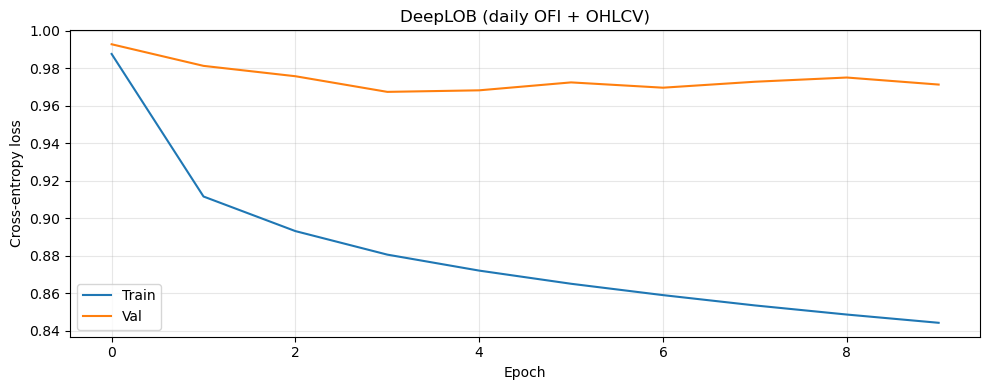

In [38]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, label="Train")
ax.plot(val_losses, label="Val")
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-entropy loss")
ax.set_title("DeepLOB (daily OFI + OHLCV)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5. Evaluation

In [39]:
# load best checkpoint
best_ckpt = os.path.join(CKPT_DIR, "deeplob_daily", "best_model.pt")
model.load_state_dict(torch.load(best_ckpt, map_location=device))
print(f"Loaded best model from {best_ckpt}")

preds, targets, probs = evaluate_model(model, dl["test"])
acc = accuracy_score(targets, preds)
print(f"\nTest accuracy: {acc:.4f}")

Loaded best model from ./checkpoints_v2/deeplob_daily/best_model.pt

Test accuracy: 0.5421


In [40]:
class_names = ["Down (0)", "Flat (1)", "Up (2)"]
print(classification_report(targets, preds, target_names=class_names, digits=4))

              precision    recall  f1-score   support

    Down (0)     0.6217    0.4436    0.5177     48292
    Flat (1)     0.4893    0.7237    0.5838     57393
      Up (2)     0.6162    0.3905    0.4780     37289

    accuracy                         0.5421    142974
   macro avg     0.5757    0.5192    0.5265    142974
weighted avg     0.5671    0.5421    0.5339    142974



In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(targets, preds)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# confusion matrix
disp = ConfusionMatrixDisplay(cm, display_labels=["Down", "Flat", "Up"])
disp.plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion matrix (test)")

# probability distribution per true class
for cls, name in enumerate(class_names):
    mask = targets == cls
    axes[1].hist(probs[mask, cls], bins=30, alpha=0.5, label=name, density=True)
axes[1].set_xlabel("P(correct class)")
axes[1].set_ylabel("Density")
axes[1].set_title("Confidence per true class")
axes[1].legend()
plt.tight_layout()
plt.show()

# summary table
from sklearn.metrics import f1_score, precision_score, recall_score

print("\n── Summary ──────────────────────────────────────────────────────────────")
print(f"  Accuracy : {acc:.4f}")
print(f"  Macro F1 : {f1_score(targets, preds, average='macro'):.4f}")
for cls, name in enumerate(["Down", "Flat", "Up"]):
    mask = targets == cls
    f1 = f1_score(targets, preds, labels=[cls], average="macro")
    prec = precision_score(targets, preds, labels=[cls], average="macro")
    rec = recall_score(targets, preds, labels=[cls], average="macro")
    print(f"  {name:4s}     precision={prec:.4f}  recall={rec:.4f}  f1={f1:.4f}  n={mask.sum():,}")